In [1]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
import joblib

**1: Load Dataset**

In [2]:
print("Loading dataset from local file...")

df = pd.read_csv("housing.csv")

print("Dataset Loaded Successfully!\n")
print(df.head())

Loading dataset from local file...
Dataset Loaded Successfully!

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY  
2       496.0       177.0         7.2574            352100.0        NEAR BAY  
3       558.0       219.0         5.6431            341300.0        NEAR BAY  
4       565.0       259.0         3.8462            342200.0        NEAR BAY  


**2: Data Cleaning**

In [12]:
# Drop categorical column if exists
if "ocean_proximity" in df.columns:
    df = df.drop("ocean_proximity", axis=1)

# Rename target column
if "median_house_value" in df.columns:
    df.rename(columns={"median_house_value": "HousePrice"}, inplace=True)

# Handle missing values
print("\nMissing values before cleaning:")
print(df.isnull().sum())

df.fillna(df.mean(), inplace=True)

print("\nMissing values after cleaning:")
print(df.isnull().sum())



Missing values before cleaning:
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
HousePrice              0
dtype: int64

Missing values after cleaning:
longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
HousePrice            0
dtype: int64


**3: Data Visualization**

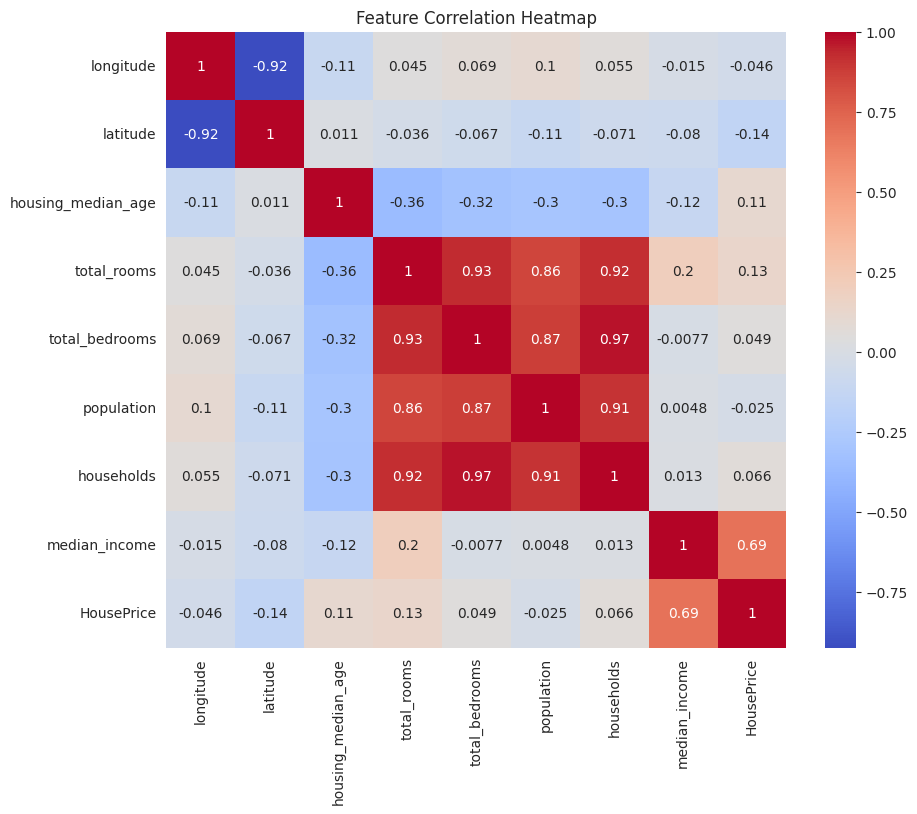

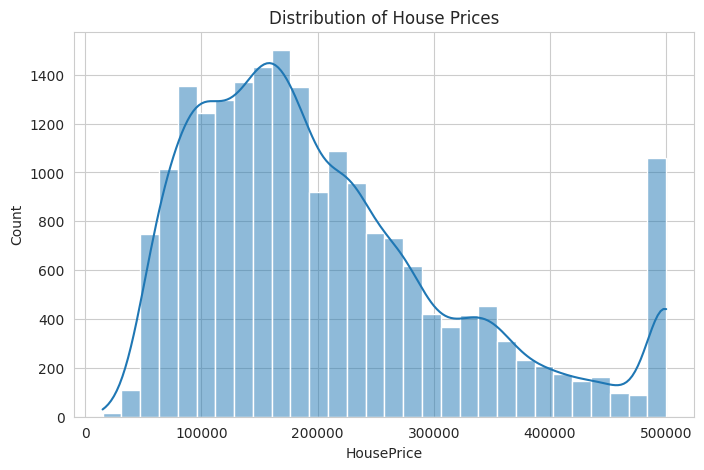

In [13]:
sns.set_style("whitegrid")

# Correlation Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

# Distribution of House Prices
plt.figure(figsize=(8,5))
sns.histplot(df["HousePrice"], bins=30, kde=True)
plt.title("Distribution of House Prices")
plt.show()

**4: Feature Selection**

In [14]:
# Selecting all features except target
X = df.drop("HousePrice", axis=1)
y = df["HousePrice"]

**5: Train Test Split**

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training and Testing Data Prepared!")

Training and Testing Data Prepared!


**6: Train Model**

In [16]:
model = LinearRegression()
model.fit(X_train, y_train)

print("Model Training Completed!")

Model Training Completed!


**7: Model Evaluation**


Model Performance:
Mean Absolute Error: 51835.73472628348
R2 Score: 0.6143987268246037


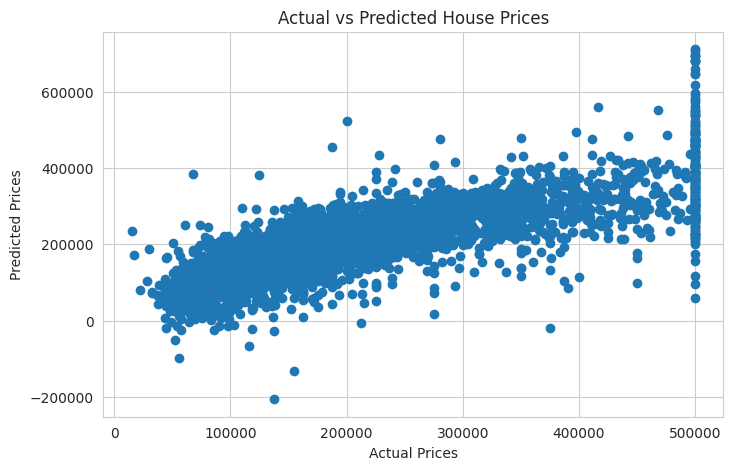

In [17]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nModel Performance:")
print("Mean Absolute Error:", mae)
print("R2 Score:", r2)

# Actual vs Predicted Plot
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")
plt.show()

**8: Save Model**

In [18]:
joblib.dump(model, "housing_model.pkl")

print("\nModel saved successfully as housing_model.pkl")


Model saved successfully as housing_model.pkl
